
# Aula de Machine Learning — Regressão Supervisionada

## Modelos abordados

- Árvore de Decisão
- Random Forest
- KNN Regressor
- SVR (Support Vector Regression)

---

## Objetivos da Aula

Ao final da aula o aluno deverá ser capaz de:

- Entender modelos supervisionados de regressão
- Implementar modelos em Python


In [1]:

# ======================================
# 1. IMPORTANDO BIBLIOTECAS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.preprocessing import StandardScaler



# Contexto do Problema

Imagine que somos uma imobiliária.

Nosso objetivo é prever o preço de uma casa utilizando:

- Área
- Número de quartos
- Idade do imóvel


In [11]:

# ======================================
# 2. CRIANDO BASE DE DADOS
# ======================================

np.random.seed(42)

n = 120

area = np.random.randint(40, 220, n)
quartos = np.random.randint(1, 6, n)
idade = np.random.randint(0, 30, n)

preco = (
    area * 4500 +
    quartos * 30000 -
    idade * 2000 +
    np.random.normal(0, 30000, n)
)

dados = pd.DataFrame({
    'area': area,
    'quartos': quartos,
    'idade': idade,
    'preco': preco
})

dados.head()


,area,quartos,idade,preco
0,142,3,27,647218.601424
1,219,1,16,968111.040471
2,132,5,1,763303.277211
3,54,2,0,305774.366147
4,146,3,15,735902.248158


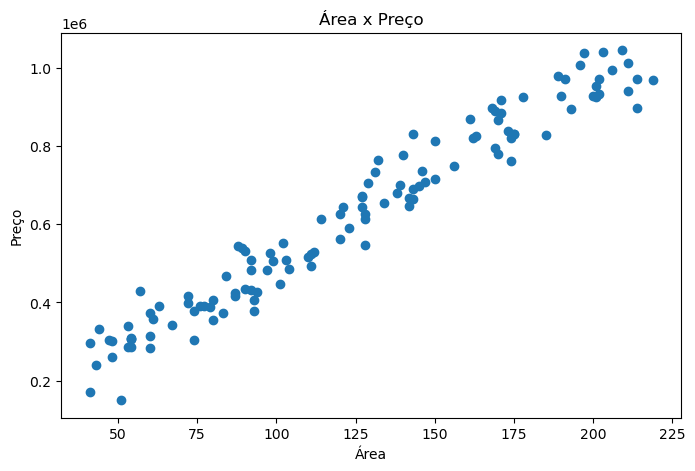

In [12]:

# ======================================
# 3. VISUALIZAÇÃO DOS DADOS
# ======================================

plt.figure(figsize=(8,5))

plt.scatter(dados['area'], dados['preco'])

plt.xlabel('Área')
plt.ylabel('Preço')
plt.title('Área x Preço')

plt.show()


In [13]:

# ======================================
# 4. DEFININDO X E y
# ======================================

X = dados[['area', 'quartos', 'idade']]
y = dados['preco']


In [10]:

# ======================================
# 5. DIVISÃO TREINO E TESTE
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)


Treino: (96, 3)
Teste: (24, 3)



# Importante — Normalização

## NÃO precisam normalização:
- Árvores
- Random Forest

## Precisam normalização:
- KNN
- SVR


In [6]:

# ======================================
# 6. NORMALIZAÇÃO
# ======================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Modelo 1 — Árvore de Decisão

A árvore aprende regras de decisão.

Exemplo:

```text
Se área < 100:
    preço menor
Senão:
    preço maior
```


In [13]:

# ======================================
# ÁRVORE DE DECISÃO
# ======================================

arvore = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

arvore.fit(X_train, y_train)

pred_arvore = arvore.predict(X_test)

mse_arvore = mean_squared_error(y_test, pred_arvore)
r2_arvore = r2_score(y_test, pred_arvore)

print('MSE:', mse_arvore)
print('R2:', r2_arvore)
  

MSE: 3763021329.589804
R2: 0.9295784601476569


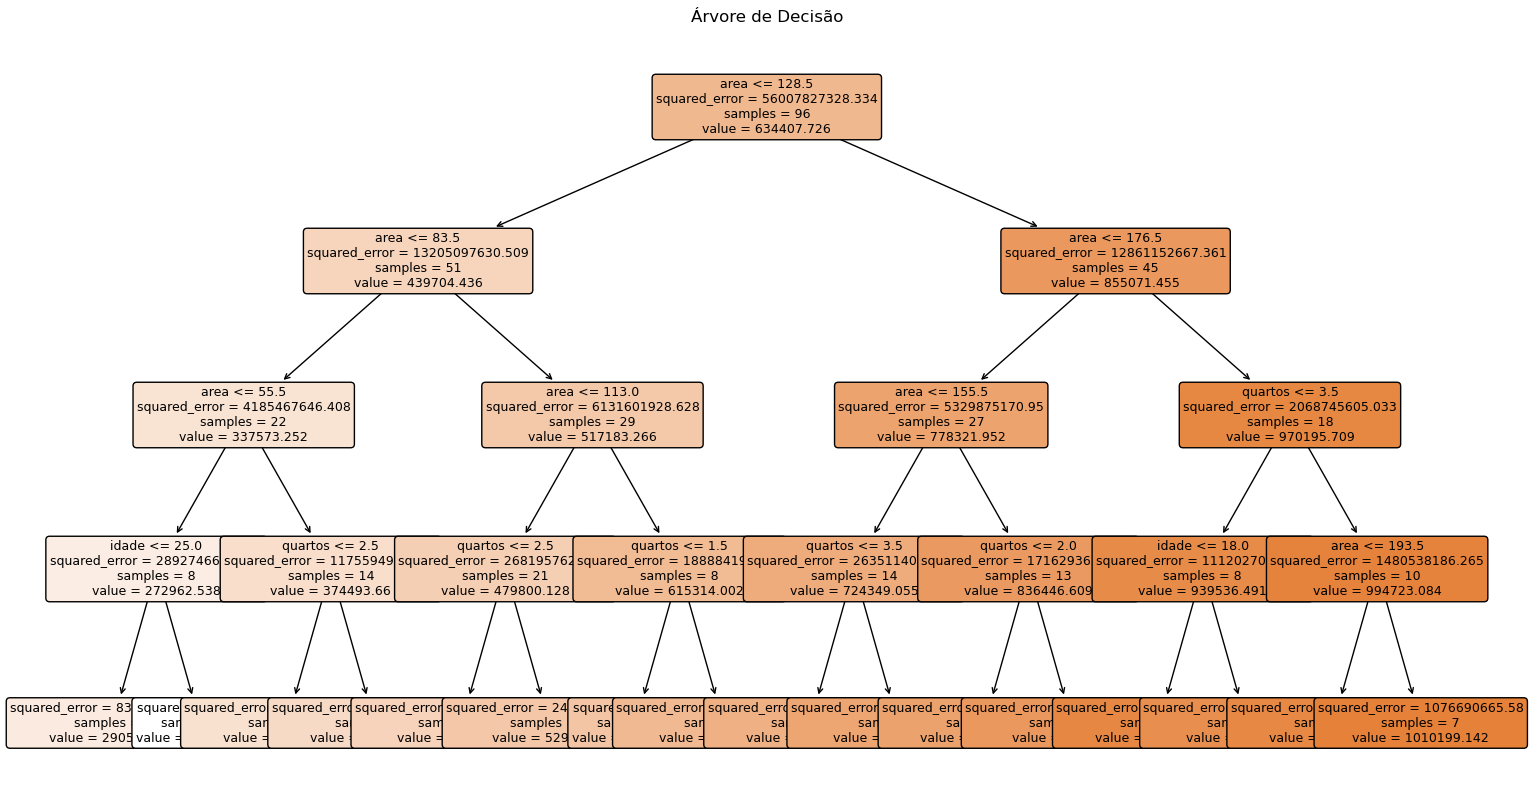

In [15]:

# ======================================
# VISUALIZANDO A ÁRVORE
# ======================================

plt.figure(figsize=(18,10))

plot_tree(
    arvore,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Árvore de Decisão')
plt.show()


NameError: name 'arvore' is not defined

<Figure size 1800x1000 with 0 Axes>


# Modelo 2 — Random Forest

Random Forest utiliza várias árvores.

A previsão final é a média das árvores.


In [15]:

# ======================================
# RANDOM FOREST
# ======================================

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

print('MSE:', mse_rf)
print('R2:', r2_rf)


MSE: 2460891430.8390865
R2: 0.9539466431916251



# Modelo 3 — KNN

O KNN utiliza os vizinhos mais próximos.


In [16]:

# ======================================
# KNN REGRESSOR
# ======================================

knn = KNeighborsRegressor(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

mse_knn = mean_squared_error(y_test, pred_knn)
r2_knn = r2_score(y_test, pred_knn)

print('MSE:', mse_knn)
print('R2:', r2_knn)


MSE: 4461958119.262669
R2: 0.9164984904432114



# Modelo 4 — SVR

SVR tenta encontrar uma curva ótima para representar os dados.


In [ ]:

# ======================================
# SVR
# ======================================

svr = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1
)

svr.fit(X_train_scaled, y_train)

pred_svr = svr.predict(X_test_scaled)

mse_svr = mean_squared_error(y_test, pred_svr)
r2_svr = r2_score(y_test, pred_svr)

print('MSE:', mse_svr)
print('R2:', r2_svr)



# Comparação Final dos Modelos


In [ ]:

# ======================================
# COMPARAÇÃO DOS MODELOS
# ======================================

resultados = pd.DataFrame({
    'Modelo': ['Árvore', 'Random Forest', 'KNN', 'SVR'],
    'R2': [r2_arvore, r2_rf, r2_knn, r2_svr],
    'MSE': [mse_arvore, mse_rf, mse_knn, mse_svr]
})

resultados


In [ ]:

# ======================================
# VISUALIZAÇÃO FINAL
# ======================================

plt.figure(figsize=(8,5))

plt.bar(resultados['Modelo'], resultados['R2'])

plt.ylabel('R2')
plt.title('Comparação entre Modelos')

plt.show()



# Exercícios para os alunos

1. Alterar max_depth
2. Alterar número de árvores
3. Alterar valor de k
4. Alterar kernel do SVR
5. Comparar resultados
